In [10]:
import sys
import networkx as nx
import osmnx as ox
import rasterio
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter

#NOTE by default OSM doesnt call the bicycle and cycleway info for performance reasons  
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway"]

bike


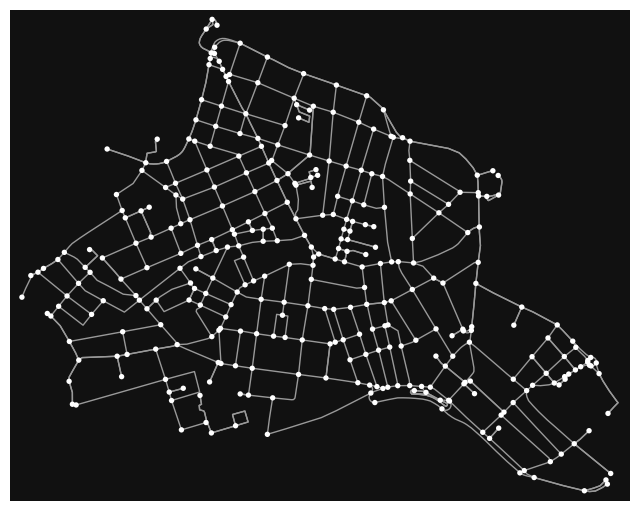

drive


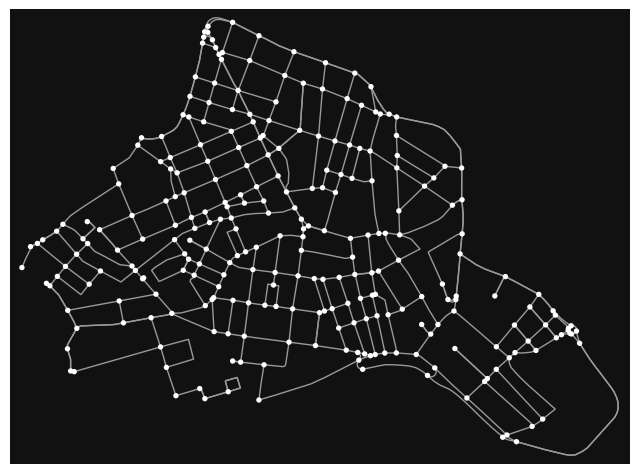

In [11]:
print("bike")

# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="bike")
fig, ax = ox.plot.plot_graph(G)

print("drive")
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSM Highway Tags Reference


Motor Vehicle Roads


- residential (26,195) - Streets in residential areas, usually low speed
- unclassified (6,501) - Minor public roads, often rural or local streets
- tertiary (5,268) - Important local roads connecting towns/villages
- secondary (4,327) - Regional roads connecting cities/large towns
- primary (1,624) - Major roads between cities, often dual carriageway
- trunk (1,378) - Major highways, national importance roads


Service & Access Roads
- service (15,417) - Service roads (parking lots, driveways, alleys)
- trunk_link (209) - Connecting ramps to trunk roads
- secondary_link (65) - Connecting ramps to secondary roads
- tertiary_link (43) - Connecting ramps to tertiary roads
- primary_link (39) - Connecting ramps to primary roads


Pedestrian & Cycling Infrastructure
- track (11,050) - Tracks for agriculture/forestry, often unpaved
- path (2,408) - Generic paths for walking/cycling
- living_street (1,040) - Shared space streets (pedestrians have priority)
- pedestrian (564) - Pedestrian-only areas/streets
- cycleway (282) - Dedicated bicycle infrastructure


Public Transport
- busway (1) - Dedicated bus lanes/roads


Road Hierarchy (Malta context)
- Trunk → Main highways
- Primary → Major arterial roads
- Secondary → Important regional roads
- Tertiary → Local connector roads
- Unclassified → Minor local roads
- Residential → Neighborhood streets

footway: 9918  #not required since If bicycles are allowed as well, you can indicate this by adding a bicycle=yes tag.


path: 2852 # Not required since, highway=cycleway for one also usable by cyclists,


pedestrian: 635? # No since bike cant directly access unless explicitly stated.


steps: 1020


corridor: 10

highway ['trunk_link', 'trunk']
highway ['trunk_link', 'trunk']
highway ['trunk_link', 'trunk']
highway ['unclassified', 'track']
highway ['unclassified', 'service']
highway ['unclassified', 'track', 'path']
highway ['unclassified', 'track']
highway ['unclassified', 'track']
highway ['unclassified', 'service']
highway ['service', 'tertiary']
highway ['service', 'residential']
highway ['path', 'residential']
highway ['service', 'track']
highway ['living_street', 'path']
highway ['track', 'path']
highway ['unclassified', 'track']
highway ['unclassified', 'track']
highway ['track', 'path']
highway ['pedestrian', 'residential']
highway ['unclassified', 'track']
highway ['service', 'track']
highway ['track', 'residential']
highway ['pedestrian', 'residential']
highway ['track', 'residential']
highway ['unclassified', 'track']
highway ['trunk_link', 'trunk']
highway ['service', 'path']
highway ['service', 'residential']
highway ['pedestrian', 'residential']
highway ['pedestrian', 'residentia

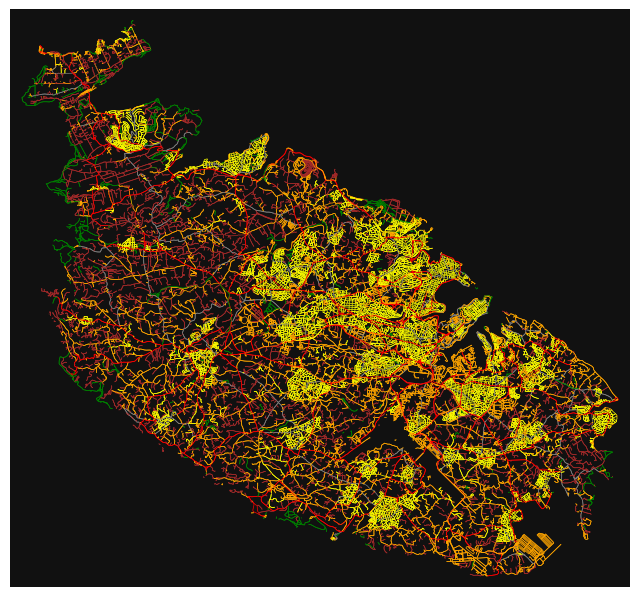

In [12]:
#TODO remove tracks from the network

#NOTE  retain_all to get all nodes even if not connected to the main network
G = ox.graph.graph_from_place("Malta (island)", network_type="bike", simplify=True, retain_all=True)
#fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

highway_color_map = {
    # SAFEST - Dedicated cycling infrastructure
    "cycleway": "green",        # Dedicated bike paths - safest
    "path": "green",           # Shared paths - generally safe
    
    # MODERATE - Cyclist-friendly streets  
    "living_street": "yellow",   # Shared space, pedestrian priority
    "residential": "yellow",        # Low speed, low traffic
    "pedestrian": "yellow",         # Walk/bike only areas

    
    # CAUTION - Mixed traffic but manageable
    "unclassified": "orange",  # Rural/local roads - variable safety
    "service": "orange",         # Parking lots, alleys - usually low speed
    #"track": "orange",            # Unpaved - may not be suitable

    # Dangerous
    "trunk":"red",
    "secondary":"red",
    "primary": "red",
    "trunk_link": "red",
    "secondary_link": "red",
    "tertiary_link": "red",
    "primary_link": "red",

    #Not suitable for urban transport / Development
    "track": "brown",
}



# Get the color for each edge based on its 'highway' attribute
edge_colors = []
highway_counts = Counter()
bikeway_counts = Counter()
cycleway_counts = Counter()
for u, v, k, data in G.edges(keys=True, data=True):
    once = False

    highway = data.get("highway")
    # Some edges may have a list of highway types
    if isinstance(highway, list): 
        print(f"highway {highway}")
        highway = highway[0]

    bicycle = data.get("bicycle")
    # Some edges may have a list of highway types
    if isinstance(bicycle, list):
        print(f"bicycle: {bicycle}")
        bicycle = bicycle[0]

    cycleway = data.get("cycleway")
    # Some edges may have a list of highway types
    if isinstance(cycleway, list): 
        print(f"cycleway: {cycleway}")
        cycleway = cycleway[0]

    # Override dangerous roads if bicycle=yes,
    # example kappara junction there is protected cycle lane on the main road 
    match(bicycle):
        case "designated": colour = "green"
        case "yes": colour = "green"
        case _: color = highway_color_map.get(highway, "gray") 
    edge_colors.append(color)

    highway_counts[highway] += 1
    bikeway_counts[bicycle] += 1
    cycleway_counts[cycleway] += 1

print("Highway type counts:")
for highway_type, count in highway_counts.most_common():
    print(f"{highway_type}: {count}")

print("-------")
print("bikeway classification type counts:")
for bikeway_type, count in bikeway_counts.most_common():
    print(f"{bikeway_type}: {count}")

print("------")
print("cycleway type counts:")
for cycleway_type, count in cycleway_counts.most_common():
    print(f"{cycleway_type}: {count}")


fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors, edge_linewidth=0.5)

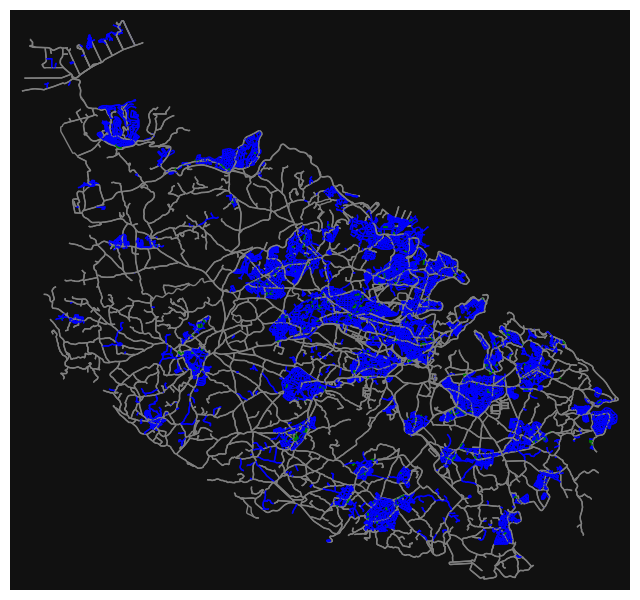

In [ ]:
cycleways = '["cycleway"~"lane|track|share_busway|shared_lane"]' # cycleway = infrastructure type (physical/painted features)
highways = '["highway"~"residential|living_street|pedestrian|footway|cycleway"]'

#NOTE There is only 1 cycleway street
#TODO SPEED LIMIT TAG
#TODO painted lane like kapara junction

#bicycles = '["bicycle"!~"no"]' # bicycle = legal access (permission/prohibition), if there is not a tag there is implied service
bicycles = '["bicycle"~"yes|designated"]'
access = '["access"!~"private"]'

cf = f'{bicycles}{access}'

#NOTE Malta (island) vs Malta to exclude Gozo and Comino

G_drive = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
G_cycle = ox.graph.graph_from_place("Sliema, Malta", custom_filter=cf)

G = nx.compose(G_drive,G_cycle)
    
highway_color_map = {
    "residential":"blue",
    "living_street": "green",
    "pedestrian": "orange",
    "footway": "purple",
    "cycleway": "red"
}

# Get the color for each edge based on its 'highway' attribute
edge_colors = []
for u, v, k, data in G.edges(keys=True, data=True):
    highway = data.get("highway")
    # Some edges may have a list of highway types; handle that
    if isinstance(highway, list):
        highway = highway[0]
    color = highway_color_map.get(highway, "gray")  # default to gray if not found
    edge_colors.append(color)

fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors)

In [14]:
# Look at a few nodes and their attributes
print("Sample nodes:")
for i, (node_id, node_data) in enumerate(G_cycle.nodes(data=True)):
    if i < 3:  # Show first 3 nodes
        print(f"Node {node_id}: {node_data}")

# Look at a few edges and their attributes
print("Sample edges:")
for i, (u, v, k, edge_data) in enumerate(G_cycle.edges(keys=True, data=True)):
    if i < 5:  # Show first 5 edges
        print(f"Edge {u} -> {v} (key: {k}): {edge_data}")

# Find all unique edge attributes
all_edge_attrs = set()
for u, v, k, data in G_cycle.edges(keys=True, data=True):
    all_edge_attrs.update(data.keys())

print("Available edge attributes:")
for attr in sorted(all_edge_attrs):
    print(f"  - {attr}")

# Find all unique node attributes
all_node_attrs = set()
for node_id, data in G_cycle.nodes(data=True):
    all_node_attrs.update(data.keys())

print("\nAvailable node attributes:")
for attr in sorted(all_node_attrs):
    print(f"  - {attr}")

Sample nodes:
Node 382980628: {'y': 35.989953, 'x': 14.3535779, 'street_count': 3}
Node 1616171059: {'y': 35.9888498, 'x': 14.3571076, 'street_count': 1}
Node 9060903996: {'y': 35.9883491, 'x': 14.3530631, 'street_count': 3}
Sample edges:
Edge 382980628 -> 148334197 (key: 0): {'osmid': 33550841, 'highway': 'residential', 'lanes': '1', 'name': "Triq ta' Maċċa", 'oneway': False, 'bicycle': 'yes', 'reversed': False, 'length': np.float64(159.38605101318484), 'geometry': <LINESTRING (14.354 35.99, 14.354 35.99, 14.354 35.99, 14.354 35.989, 14.354...>}
Edge 382980628 -> 382980742 (key: 0): {'osmid': 33550866, 'highway': 'residential', 'lanes': '1', 'name': "Triq ta' Maċċa", 'oneway': False, 'bicycle': 'yes', 'reversed': True, 'length': np.float64(129.0416697866274), 'geometry': <LINESTRING (14.354 35.99, 14.353 35.99, 14.353 35.99, 14.353 35.99, 14.353 ...>}
Edge 382980628 -> 382980558 (key: 0): {'osmid': [1366547510, 668597015], 'highway': 'residential', 'lanes': '1', 'name': ["Triq il-Batt

# Topology


In [15]:
"""raster_path = "../Data/ebk1km1.tif"
G = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)
G = ox.elevation.add_edge_grades(G, add_absolute=True)"""

'raster_path = "../Data/ebk1km1.tif"\nG = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)\nG = ox.elevation.add_edge_grades(G, add_absolute=True)'

DEM info:
Bounds: BoundingBox(left=14.303194433333346, bottom=35.78736112222222, right=14.632916655555567, top=36.00458334444444)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
CRS: EPSG:4326


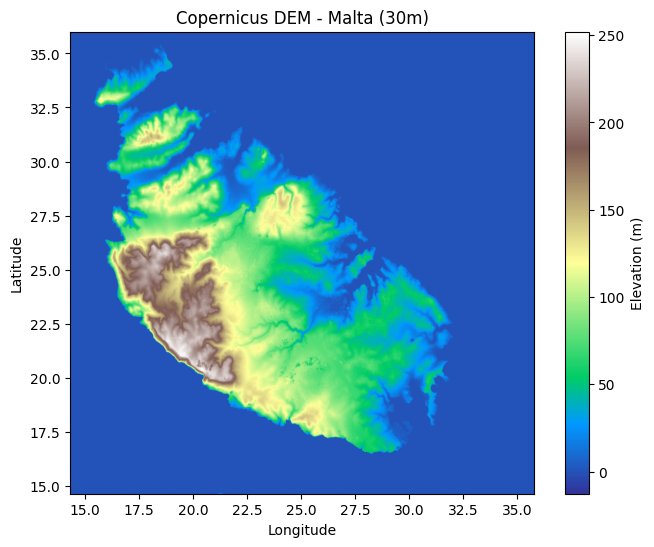

In [16]:
# path to your Copernicus DEM GeoTIFF
raster_path = "../Data/rasters_COP30.tif"

# open the raster
raster = rasterio.open(raster_path)

# print metadata to verify
print("DEM info:")
print(f"Bounds: {raster.bounds}")
print(f"Resolution: {raster.res}")
print(f"CRS: {raster.crs}")

# read the first (and only) band
elevation = raster.read(1)

# mask no-data values (these appear as very low or high numbers)
elevation = elevation.astype(float)
elevation[elevation <= -100] = float('nan')

# plot
plt.figure(figsize=(8, 6))
plt.imshow(elevation, cmap="terrain", extent=raster.bounds)
plt.colorbar(label="Elevation (m)")
plt.title("Copernicus DEM - Malta (30m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [17]:
node_colors = ox.plot.get_node_colors_by_attr(G_bike, "elevation", cmap="viridis")
fig, ax = ox.plot.plot_graph(G_bike, node_color=node_colors, node_size=5, edge_linewidth=0.5)


NameError: name 'G_bike' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get all grade_abs values
grade_abs_values = [data.get("grade_abs", 0) for u, v, k, data in G_bike.edges(keys=True, data=True) if data.get("grade_abs") is not None]

# Create histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of all values
ax1.hist(grade_abs_values, bins=50, alpha=0.7, color='blue')
ax1.set_xlabel('Grade Absolute')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Grade Absolute Values')
ax1.grid(True, alpha=0.3)

# Zoom in on reasonable values (exclude extreme outliers)
reasonable_grades = [g for g in grade_abs_values if g < 0.5]  # Less than 50% grade
ax2.hist(reasonable_grades, bins=30, alpha=0.7, color='green')
ax2.set_xlabel('Grade Absolute (< 0.5)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution (Excluding Extreme Values)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Edges with grade > 50%: {len([g for g in grade_abs_values if g > 0.5])}")
print(f"Edges with grade > 100%: {len([g for g in grade_abs_values if g > 1.0])}")

# Basic street network stats

In [18]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

275524219.5147742

In [19]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 15780,
 'm': 35608,
 'k_avg': 4.513054499366286,
 'edge_length_total': 3321904.9589776746,
 'edge_length_avg': 93.29097278638717,
 'streets_per_node_avg': 2.849619771863118,
 'streets_per_node_counts': {0: 0,
  1: 1898,
  2: 216,
  3: 12072,
  4: 1555,
  5: 33,
  6: 6},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.12027883396704689,
  2: 0.013688212927756654,
  3: 0.7650190114068441,
  4: 0.0985424588086185,
  5: 0.002091254752851711,
  6: 0.00038022813688212925},
 'intersection_count': 13882,
 'street_length_total': 1990686.3459606594,
 'street_segment_count': 22527,
 'street_length_avg': 88.36890602213607,
 'circuity_avg': 1.0706844803490096,
 'self_loop_proportion': 0.0010653882008256758,
 'clean_intersection_count': 8625,
 'node_density_km': 57.27264204863792,
 'intersection_density_km': 50.38395544481569,
 'edge_density_km': 12056.671333024307,
 'street_density_km': 7225.086598435731,
 'clean_intersection_density_km': 31.30396309692662}

# Visualize street centrality

In [20]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

KeyboardInterrupt: 

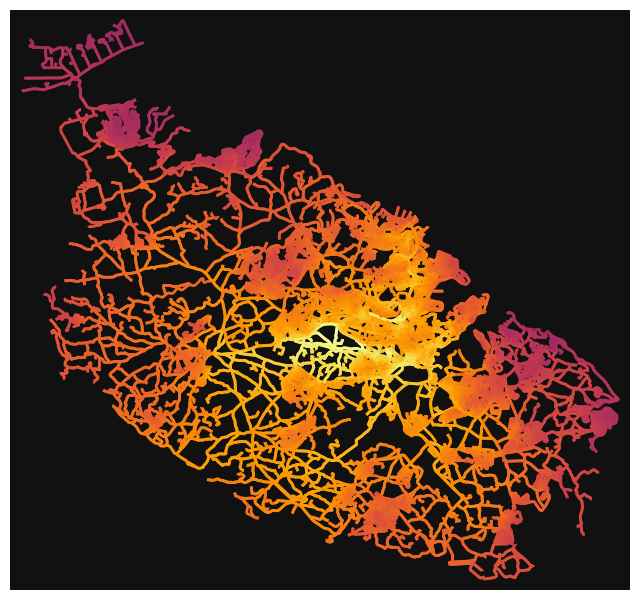

In [ ]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

# Routing

In [ ]:
# impute missing edge speeds and calculate edge travel times with the speed module
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

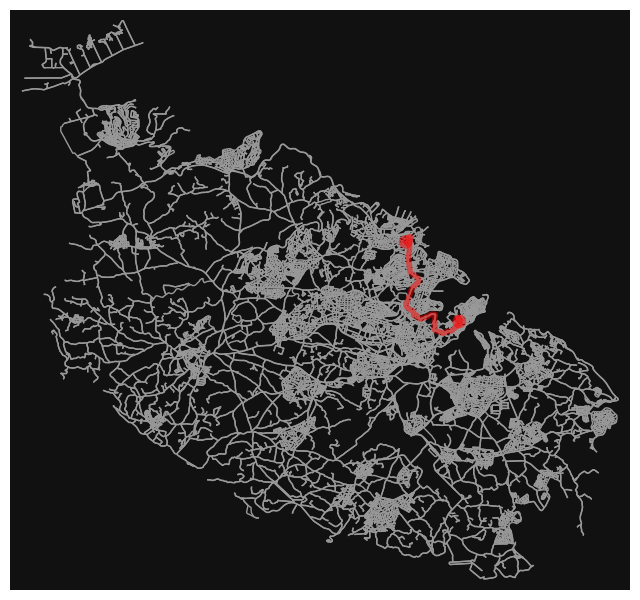

In [ ]:
# get the nearest network nodes to two lat/lng points with the distance module
orig = ox.distance.nearest_nodes(G, X=35.893385, Y=14.477465)
dest = ox.distance.nearest_nodes(G, X=35.890245, Y=14.479616)

orig = next(iter(G))
dest = list(G)[-1]

# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [ ]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

6951

In [ ]:
# how far is it between these two nodes as the crow flies?
# use OSMnx's vectorized great-circle distance (haversine) function
orig_x = G.nodes[orig]["x"]
orig_y = G.nodes[orig]["y"]
dest_x = G.nodes[dest]["x"]
dest_y = G.nodes[dest]["y"]
round(ox.distance.great_circle(orig_y, orig_x, dest_y, dest_x))

3601

Found 523 edges with parking information

Parking type counts:
none: 35052
lane: 330
no: 155
side_parking: 36
street_side: 2


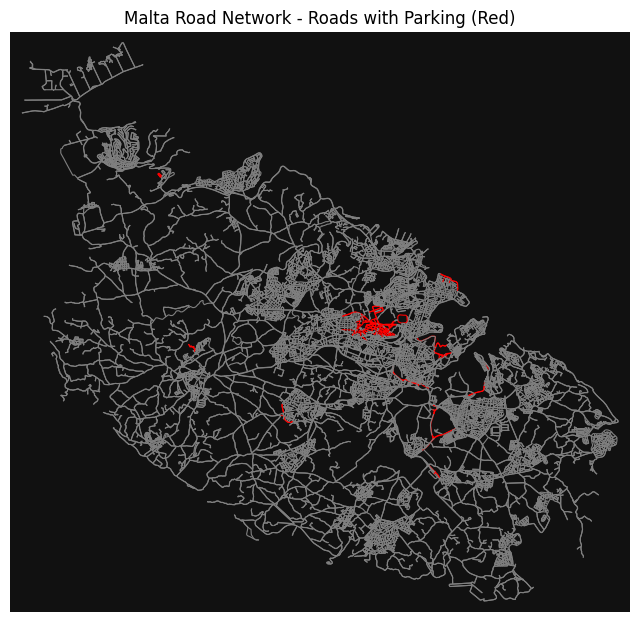

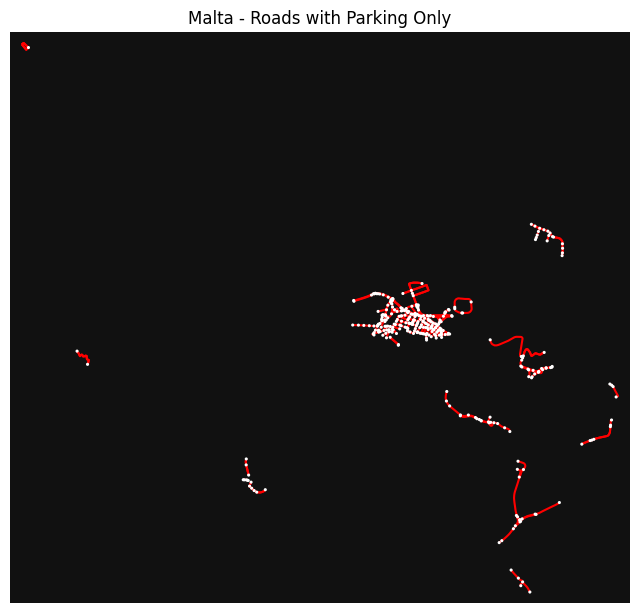

In [ ]:
# Add parking-related tags to OSMnx settings
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["parking", "parking:lane", "parking:both", "parking:left", "parking:right"]

# Download network with parking data
G = ox.graph_from_place("Malta (island)", network_type="drive")

# Find edges with parking information
parking_edges = []
edge_colors = []
parking_counts = Counter()

for u, v, k, data in G.edges(keys=True, data=True):
    has_parking = False
    parking_type = "none"
    
    # Check various parking tags
    parking = data.get("parking")
    parking_lane = data.get("parking:lane") 
    parking_both = data.get("parking:both")
    parking_left = data.get("parking:left")
    parking_right = data.get("parking:right")
    
    if parking or parking_lane or parking_both or parking_left or parking_right:
        has_parking = True
        parking_type = parking or parking_lane or parking_both or "side_parking"
        
        # Handle case where parking_type is a list
        if isinstance(parking_type, list):
            parking_type = parking_type[0]
        
        parking_edges.append((u, v, k, data))
        edge_colors.append("red")  # Red for roads with parking
    else:
        edge_colors.append("gray")  # Gray for roads without parking
    
    parking_counts[parking_type] += 1

print(f"Found {len(parking_edges)} edges with parking information")
print("\nParking type counts:")
for parking_type, count in parking_counts.most_common():
    print(f"{parking_type}: {count}")

# Plot the network highlighting parking areas
fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors, edge_linewidth=0.8, show=False, close=False)
plt.title("Malta Road Network - Roads with Parking (Red)")
plt.show()

# Create a detailed view of just parking roads
if parking_edges:
    parking_edge_colors = ["red"] * len(parking_edges)
    parking_graph = G.edge_subgraph([(u, v, k) for u, v, k, data in parking_edges])
    fig, ax = ox.plot_graph(parking_graph, node_size=5, edge_color=parking_edge_colors, edge_linewidth=1.5,  show=False, close=False)
    plt.title("Malta - Roads with Parking Only")
    plt.show()